<a href="https://colab.research.google.com/github/harshvardhaniimi/sba-moda-workshop/blob/main/Pokemon_Workshop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔥💧🌿 Two Classifiers for Pokémon Types

*Workshop by Dr. Harshvardhan · American University of Sharjah · Organized by SBA MODA and BAA.*

---

Today we will teach a computer to look at a Pokémon and guess whether it is **Fire**, **Water**, or **Grass** type — using only the colours in the image.

We will build three machine-learning models and compare them. Along the way we will learn two big lessons:

1. **Hyperparameter tuning** is useful but not magic
2. **Picking the right model family** often matters more than tuning

There is also an optional **Bonus** section at the end exploring PCA.

Run each grey cell from top to bottom. Click inside the cell and press **Shift + Enter**.

## Step 0 — Get the data

First, download the Pokémon images from our workshop repo. This works the same way on your laptop and on Google Colab — the cell only downloads if the data is not already there.

In [2]:
import os, urllib.request, zipfile

# Where the data lives in our GitHub repo
DATA_URL = "https://github.com/harshvardhaniimi/sba-moda-workshop/raw/main/pokemon_data.zip"
DATA_DIR = "pokemon_data"

# Download and unzip if the folder is not already present
if not os.path.isdir(DATA_DIR):
    print("Downloading data (~2.3 MB) ...")
    urllib.request.urlretrieve(DATA_URL, "pokemon_data.zip")
    with zipfile.ZipFile("pokemon_data.zip", "r") as z:
        z.extractall(".")
    print("Done.")
else:
    print("Data already present, skipping download.")

Data already present, skipping download.


## Step 1 — Bring in the tools we need

Before we can do anything, we have to import some Python libraries. We will start with three core ones for numbers, tables, and charts.

In [3]:
# numpy gives us fast arrays and basic math
import numpy as np

# pandas lets us read the CSV file with the Pokémon labels
import pandas as pd

# matplotlib draws charts and shows images
import matplotlib.pyplot as plt

Now that we have the basics, we also need to open image files and build file paths.

In [4]:
# PIL (Pillow) is the standard library for opening image files in Python
from PIL import Image

# pathlib helps us write file paths in a clean, cross-platform way
from pathlib import Path

Finally, the machine-learning tools from **scikit-learn** — both the models and the helpers we need to evaluate them.

In [5]:
# Splits our data into a training set and a test set
from sklearn.model_selection import train_test_split

# The two models we will compare today
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Tools for measuring how well the models do
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

## Step 2 — Load the labels

Now we have all the libraries. The next thing we need is the **labels** — a CSV file that tells us each Pokémon's name and type.

In [6]:
# Path to the CSV file inside the downloaded data folder
csv_path = "pokemon_data/pokemon.csv"

# Read the CSV into a pandas DataFrame (a table)
labels_df = pd.read_csv(csv_path)

We have the table loaded. Let's peek at the first few rows to see what's inside.

In [7]:
# .head() returns the first 5 rows by default
labels_df.head()

,Name,Type1,Type2
0,bulbasaur,Grass,Poison
1,ivysaur,Grass,Poison
2,venusaur,Grass,Poison
3,charmander,Fire,NaN
4,charmeleon,Fire,NaN


Each Pokémon has a `Type1` (main type) and sometimes a `Type2` (secondary type). We will only use `Type1`. Let's see how many different types exist and how many Pokémon belong to each.

In [8]:
# .value_counts() counts how often each value appears in a column
labels_df["Type1"].value_counts()

Type1
Water       114
Normal      105
Grass        78
Bug          72
Fire         53
Psychic      53
Rock         46
Electric     40
Poison       34
Ground       32
Fighting     29
Dark         29
Ghost        27
Dragon       27
Steel        26
Ice          23
Fairy        18
Flying        3
Name: count, dtype: int64

Eighteen types is a lot to start with. To keep our first model simple and easy to interpret, we will pick three very different types: **Fire**, **Water**, and **Grass**.

In [9]:
# The three types we want to keep
chosen_types = ["Fire", "Water", "Grass"]

# Keep only rows whose Type1 is one of those three
labels_df = labels_df[labels_df["Type1"].isin(chosen_types)]

# Reset the row numbers so they run 0, 1, 2, ... again
labels_df = labels_df.reset_index(drop=True)

Let's confirm how many Pokémon we have left in each of the three types.

In [10]:
labels_df["Type1"].value_counts()

Type1
Water    114
Grass     78
Fire      53
Name: count, dtype: int64

## Step 3 — Look at one image

We have the labels, but we have not yet looked at a single picture. Pokémon images are PNG files with **transparent backgrounds**. To get clean colour statistics later, we will paste each image onto a **white background** first. Let's write a small helper function for that.

In [11]:
def load_image(path):
    """Open a Pokémon PNG and put it on a white background."""
    # Open the file as RGBA (Red, Green, Blue + Alpha for transparency)
    rgba = Image.open(path).convert("RGBA")
    
    # Make a plain white image of the same size
    white = Image.new("RGB", rgba.size, "white")
    
    # Paste the Pokémon onto the white background, using the alpha channel as a mask
    white.paste(rgba, mask=rgba.split()[3])
    return white

Now we have a helper. Let's use it to load and display the first Pokémon in our table.

In [12]:
# Folder where all the Pokémon image files live
images_folder = Path("pokemon_data/images")

# Take the name of the first Pokémon in our filtered table
first_name = labels_df.loc[0, "Name"]

# Build the path to its image and load it
first_image = load_image(images_folder / f"{first_name}.png")

We have an image object. Let's actually display it on screen.

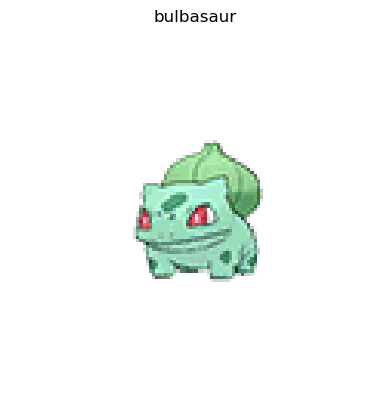

In [13]:
# Show the image with the Pokémon's name as the title
plt.imshow(first_image)
plt.title(first_name)
plt.axis("off")
plt.show()

Behind the scenes, an image is just a grid of numbers. Each pixel has three values: how much **Red**, **Green**, and **Blue** light it has. Let's confirm by checking the shape of the underlying array.

In [14]:
# Convert the image to a numpy array of pixel values
first_array = np.array(first_image)

# .shape returns (height, width, colour_channels)
print("Image shape:", first_array.shape)

Image shape: (120, 120, 3)


## Step 4 — Turn each image into a few numbers (features)

A 120 × 120 × 3 picture has more than 43,000 numbers. That is far too many to feed straight into a model. We need to **summarise** each image as a small list of numbers — its **features**.

The simplest possible summary: the **average Red, Green, and Blue value** across all pixels. That gives us just **three numbers per Pokémon**.

Let's write a function that takes an image path and returns those three numbers.

In [ ]:
def image_to_features(image_path):
    """Return [avg_red, avg_green, avg_blue] for one Pokémon image."""
    # Load the image (with white background) and turn it into a numpy array
    arr = np.array(load_image(image_path))
    
    # arr has shape (height, width, 3). The last axis is R, G, B.
    avg_red   = arr[:, :, 0].mean()
    avg_green = arr[:, :, 1].mean()
    avg_blue  = arr[:, :, 2].mean()
    
    return [avg_red, avg_green, avg_blue]

Quick sanity check — let's try the function on the first Pokémon and see what numbers come out.

In [18]:
print(f"Pokemoń {first_name} has RGB channels as: ")
image_to_features(images_folder / f"{first_name}.png")

Pokemoń bulbasaur has RGB channels as: 


[np.float64(243.9638888888889),
 np.float64(249.00541666666666),
 np.float64(245.95256944444444)]

It works on one Pokémon. Now we loop over **every** Pokémon in our filtered table and collect the features for all of them.

In [19]:
# Empty lists we will fill as we go through the table
all_features = []   # this will become our X (the inputs)
all_labels   = []   # this will become our y (the targets)

# Loop through every row of the labels table
for _, row in labels_df.iterrows():
    image_path = images_folder / f"{row['Name']}.png"
    
    # Skip silently if the image file is missing
    if not image_path.exists():
        continue
    
    # Extract features and remember the type label
    all_features.append(image_to_features(image_path))
    all_labels.append(row["Type1"])
    
    # Print what was done
    print(f"Processed details for Pokemoń: {row['Name']}")

Processed details for Pokemoń: bulbasaur
Processed details for Pokemoń: ivysaur
Processed details for Pokemoń: venusaur
Processed details for Pokemoń: charmander
Processed details for Pokemoń: charmeleon
Processed details for Pokemoń: charizard
Processed details for Pokemoń: squirtle
Processed details for Pokemoń: wartortle
Processed details for Pokemoń: blastoise
Processed details for Pokemoń: vulpix
Processed details for Pokemoń: ninetales
Processed details for Pokemoń: oddish
Processed details for Pokemoń: gloom
Processed details for Pokemoń: vileplume
Processed details for Pokemoń: psyduck
Processed details for Pokemoń: golduck
Processed details for Pokemoń: growlithe
Processed details for Pokemoń: arcanine
Processed details for Pokemoń: poliwag
Processed details for Pokemoń: poliwhirl
Processed details for Pokemoń: poliwrath
Processed details for Pokemoń: bellsprout
Processed details for Pokemoń: weepinbell
Processed details for Pokemoń: victreebel
Processed details for Pokemoń: t

We collected the data into Python lists. Let's convert them to numpy arrays — the format that scikit-learn expects.

In [20]:
# X is the feature matrix; y is the vector of labels
X = np.array(all_features)
y = np.array(all_labels)

# Always check the shapes after building data
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (218, 3)
y shape: (218,)


## Step 5 — Split the data into training and test sets

If we train and test the model on the **same** data, it can simply memorise the answers. To be honest about how well our model really learned, we **hold back 25%** of the Pokémon — the model never sees them during training.

In [21]:
# train_test_split shuffles and splits in one go
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,      # keep 25% for testing
    random_state=42,     # fixed seed -> same split every time we run
    stratify=y           # keep the class proportions balanced in both halves
)

Quick sanity check on the size of each set.

In [22]:
print("Training Pokémon:", len(X_train))
print("Testing Pokémon: ", len(X_test))

Training Pokémon: 163
Testing Pokémon:  55


## Step 6 — Model 1: Random Forest 🌲🌲🌲

A **Random Forest** is a collection of decision trees. Each tree is trained on a slightly different chunk of the data and learns slightly different rules. To classify a new Pokémon, every tree casts a vote and the majority answer wins.

It is like asking 100 Pokémon professors to each guess independently and going with the most popular answer.

First we **create** the model. Nothing has been trained yet — we are just building an empty forest.

In [23]:
# A forest of 100 trees, with a fixed random seed for reproducibility
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

Now we **train** it. The `.fit()` method is where the actual learning happens — the trees grow themselves to fit the training data.

In [24]:
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Training is done. Now we ask the model to **predict** the type of every Pokémon in the test set — Pokémon it has never seen before.

In [25]:
rf_predictions = rf_model.predict(X_test)

How often was the model right? That's the **accuracy** — the share of test Pokémon it classified correctly.

In [26]:
# Compare predictions to the true labels
rf_accuracy = accuracy_score(y_test, rf_predictions)

# Print as a percentage with one decimal
print(f"Random Forest accuracy: {rf_accuracy:.1%}")

Random Forest accuracy: 72.7%


Accuracy is a single number. To see *where* the model gets confused, we draw a **confusion matrix** — a table of actual vs predicted types.

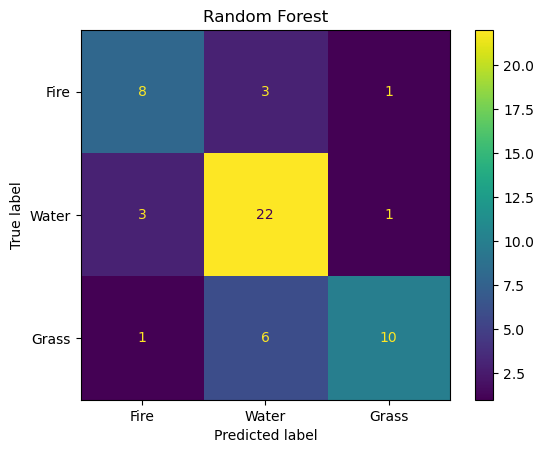

In [27]:
# Build the matrix: rows = actual type, columns = predicted type
rf_cm = confusion_matrix(y_test, rf_predictions, labels=chosen_types)

# Plot it as a labelled heatmap
ConfusionMatrixDisplay(rf_cm, display_labels=chosen_types).plot()
plt.title("Random Forest")
plt.show()

## Step 7 — Model 2: Logistic Regression

Now let's try a completely different kind of model. **Logistic Regression** does *not* build trees. Instead it tries to draw straight-line boundaries between the classes in feature space. Despite the name, it is used for **classification**, not regression.

It is much simpler than a Random Forest — and sometimes simpler is enough.

Create the model. We allow it to take up to 1,000 iterations to find a good fit.

In [28]:
lr_model = LogisticRegression(
    max_iter=1000,        # how long the optimiser is allowed to run
    random_state=42
)

Train it on exactly the same training data we used for the Random Forest.

In [29]:
lr_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

Predict on the same held-out test set.

In [30]:
lr_predictions = lr_model.predict(X_test)

Compute the accuracy for the Logistic Regression.

In [31]:
lr_accuracy = accuracy_score(y_test, lr_predictions)
print(f"Logistic Regression accuracy: {lr_accuracy:.1%}")

Logistic Regression accuracy: 76.4%


And the confusion matrix for this model too — same recipe as before.

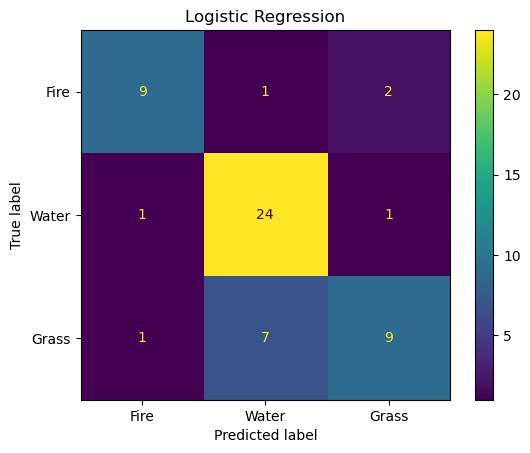

In [32]:
lr_cm = confusion_matrix(y_test, lr_predictions, labels=chosen_types)
ConfusionMatrixDisplay(lr_cm, display_labels=chosen_types).plot()
plt.title("Logistic Regression")
plt.show()

## Step 8 — Compare the two models

Both models did their best. Let's put their accuracies side by side in a single bar chart.

In [33]:
# Names and scores in the same order
model_names  = ["Random Forest", "Logistic Regression"]
model_scores = [rf_accuracy, lr_accuracy]

Now draw the bars and label each one with its accuracy.

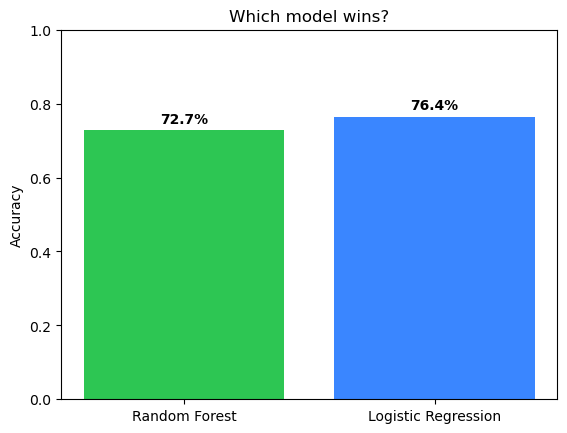

In [34]:
# Draw the two bars in different colours
plt.bar(model_names, model_scores, color=["#2DC653", "#3A86FF"])
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Which model wins?")

# Write each accuracy on top of its bar
for i, score in enumerate(model_scores):
    plt.text(i, score + 0.02, f"{score:.1%}", ha="center", fontweight="bold")

plt.show()

## Step 9 — Why did Random Forest lose? Hyperparameter tuning

That is a surprising result. Random Forest is usually the *more powerful* model — yet here it lost to the simpler Logistic Regression. Why?

- We only have **3 features** per Pokémon. Random Forests shine when there are many features and complex non-linear patterns to find.
- The problem here is **roughly linear**: red Pokémon tend to be Fire, blue tend to be Water, green tend to be Grass. That is exactly where Logistic Regression's straight-line boundaries are a natural fit.

Still — can we squeeze a bit more out of Random Forest by **tuning its hyperparameters**? Hyperparameters are the knobs we set *before* training (number of trees, depth of each tree, etc.). The defaults are reasonable, but maybe better values exist for our problem.

### Hyperparameters in Random Forest

The most important hyperparameters in a Random Forest are:
- `n_estimators`: how many trees to grow in the forest
- `max_depth`: how deep each tree is allowed to grow
- `min_samples_split`: the minimum number of samples required to split an internal node
- `min_samples_leaf`: the minimum number of samples required to be at a leaf node

In our example, we will only tune `n_estimators` and `max_depth` to keep things simple. We will try 5 different values for each, giving us 25 different combinations to test.

We will use `GridSearchCV`. It tries every combination of hyperparameter values, scoring each one with **cross-validation** (training and testing on different chunks of the training data). It then tells us which combination scored best.

In [36]:
# GridSearchCV is sklearn's tool for trying many hyperparameter combinations
from sklearn.model_selection import GridSearchCV

First we define the **grid** — every combination of values we want to try. We will tune two knobs.

In [37]:
# 3 values times 3 values = 9 combinations to test in total
param_grid = {
    "n_estimators": [50, 100, 200],   # number of trees in the forest
    "max_depth":    [3, 5, 10],       # how deep each tree is allowed to grow
}

Now wrap a fresh Random Forest inside a `GridSearchCV` with **5-fold cross validation** — for each combination it splits the training data into 5 chunks, trains on 4 and tests on 1, repeated five times.

In [38]:
# This object will run 9 x 5 = 45 small experiments under the hood
rf_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,         # 5-fold cross validation
    n_jobs=-1     # use all CPU cores in parallel
)

Run the search. This may take a few seconds.

In [40]:
rf_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 :

Which combination scored best on the cross-validation folds?

In [41]:
print("Best parameters:", rf_search.best_params_)
print(f"Best cross-validation score: {rf_search.best_score_:.1%}")

Best parameters: {'max_depth': 10, 'n_estimators': 50}
Best cross-validation score: 65.6%


GridSearchCV automatically refits the best model on **all** the training data. We can use it directly to predict on our held-out test set.

In [42]:
rf_tuned_predictions = rf_search.predict(X_test)
rf_tuned_accuracy = accuracy_score(y_test, rf_tuned_predictions)
print(f"Tuned Random Forest accuracy: {rf_tuned_accuracy:.1%}")

Tuned Random Forest accuracy: 70.9%


## Step 10 — Compare all three models

Now we have three results to compare. Let's redraw the bar chart with all of them.

In [43]:
# Three models, three scores
three_names  = ["Random Forest\n(default)", "Random Forest\n(tuned)", "Logistic Regression"]
three_scores = [rf_accuracy, rf_tuned_accuracy, lr_accuracy]

Draw the bars.

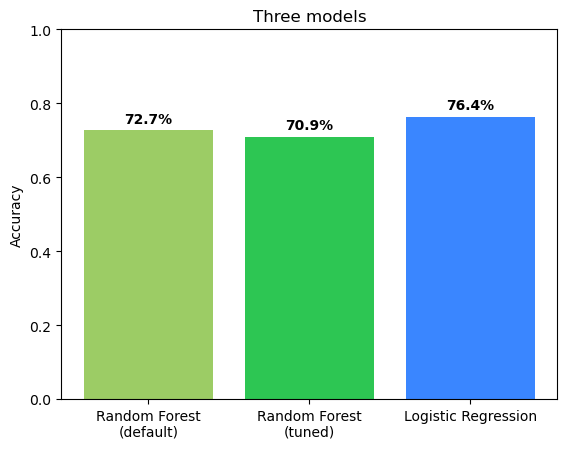

In [44]:
# Three bars in three colours
plt.bar(three_names, three_scores, color=["#9CCC65", "#2DC653", "#3A86FF"])
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Three models")

for i, score in enumerate(three_scores):
    plt.text(i, score + 0.02, f"{score:.1%}", ha="center", fontweight="bold")

plt.show()

## The two big lessons

Look at the bars carefully. Notice anything?

> **Lesson 1 — Hyperparameter tuning is useful but not magic.** Tuning the Random Forest barely moved the needle. It actually made the base model slightly worse.
>
> **Lesson 2 — Picking the right *model family* often matters more than tuning.** A simple Logistic Regression beat both Random Forests because the problem is roughly linear (red→Fire, blue→Water, green→Grass).

Hyperparameter tuning and Random Forests are both powerful tools. But neither is a substitute for **thinking carefully about which model fits your problem**.

## Wrap-up

Here is the full pipeline we just built:

| Step | What we did |
|---|---|
| 0 | Downloaded the Pokémon images from the workshop GitHub repo |
| 1 | Imported the libraries we needed |
| 2 | Loaded the Pokémon labels from a CSV |
| 3 | Looked at one image and learned that an image is a grid of numbers |
| 4 | Turned every image into 3 numbers: average Red, Green, Blue |
| 5 | Split the data into a training set (75%) and a test set (25%) |
| 6 | Trained a **Random Forest** and measured its accuracy |
| 7 | Trained a **Logistic Regression** and measured its accuracy |
| 8 | Compared the two models — Logistic Regression won |
| 9 | Tuned the Random Forest with `GridSearchCV` |
| 10 | Compared all three models |

### Why isn't the accuracy 100%?

Some Pokémon don't follow the colour stereotype — a Grass-type might be brown, a Fire-type might be black. Our models only see colour, nothing else.

### How would we make it better?

- Add **shape and texture features** (edges, corners, symmetry)
- Try **gradient boosting** (`xgboost`, `lightgbm`) or **support vector machines**
- Use a **convolutional neural network** that learns features directly from raw pixels — these dominate modern image classification

But the lesson stands: even with three simple numbers per image, a basic model can do far better than random guessing — and sometimes the simple model is also the best one.

---

# 🎁 Bonus — Could MORE features do better?

*This section is optional. We won't cover it in the workshop, but it explores a useful technique called **PCA** (Principal Component Analysis) and reveals a third surprising lesson. Try it at home!*

So far we summarised each image as 3 numbers (average R, G, B). What if we let the model see *every* pixel and figure out for itself what matters?

Each image is 120 × 120 × 3 = **43,200 numbers**. Let's flatten that into one long vector per Pokémon and see what happens.

In [45]:
# Empty list to hold the flattened pixel vectors
all_pixels = []

# Loop again, this time keeping every pixel value
for _, row in labels_df.iterrows():
    image_path = images_folder / f"{row['Name']}.png"
    if not image_path.exists():
        continue
    arr = np.array(load_image(image_path))    # shape (120, 120, 3)
    all_pixels.append(arr.flatten())          # shape (43200,)

Stack the vectors into a matrix and check the shape.

In [46]:
X_pixels = np.array(all_pixels)
print("Pixel matrix shape:", X_pixels.shape)

Pixel matrix shape: (218, 43200)


**218 Pokémon, 43,200 features each.** That is *way* more features than rows of data. With so many knobs, models train slowly and easily overfit. We need a way to **shrink** the feature count.

## PCA — shrink many features into a few

**Principal Component Analysis (PCA)** finds the directions of biggest variation in the data and keeps only the top few. Think of it like compressing a song — keep what matters most, throw away the rest.

We will compress 43,200 features down to just **50 components**. In other words, we will let PCA find 50 new features that are combinations of the original pixels that best represent the original images' data.

In [47]:
from sklearn.decomposition import PCA

Split the pixel data into the same training and test rows we used before (same `random_state` and `stratify=y`).

In [48]:
Xp_train, Xp_test, _, _ = train_test_split(
    X_pixels, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

Fit PCA on the **training pixels only** (we must never let the test set leak into our training process), then apply the same transformation to both sets.

In [49]:
# Build a PCA that keeps the top 50 components
pca = PCA(n_components=50, random_state=42)

# Learn the components from the training data, then transform both sets
Xp_train_pca = pca.fit_transform(Xp_train)
Xp_test_pca  = pca.transform(Xp_test)

Check the new shape and how much of the original information PCA managed to keep.

In [50]:
print("New shape:", Xp_train_pca.shape)
print(f"Variance explained by 50 components: {pca.explained_variance_ratio_.sum():.1%}")

New shape: (163, 50)
Variance explained by 50 components: 75.0%


We went from 43,200 numbers to 50 numbers per Pokémon — a **860× reduction** — while keeping a big chunk of the variation in the data (75%).

### Visualise Pokémon in 2D

PCA is also a great visualisation tool. Let's reduce the pixels all the way down to **just 2 components** and plot every Pokémon as a dot, coloured by its type.

In [52]:
# Quick 2-component PCA on all pixel data
pca2 = PCA(n_components=2, random_state=42)
X_2d = pca2.fit_transform(X_pixels)

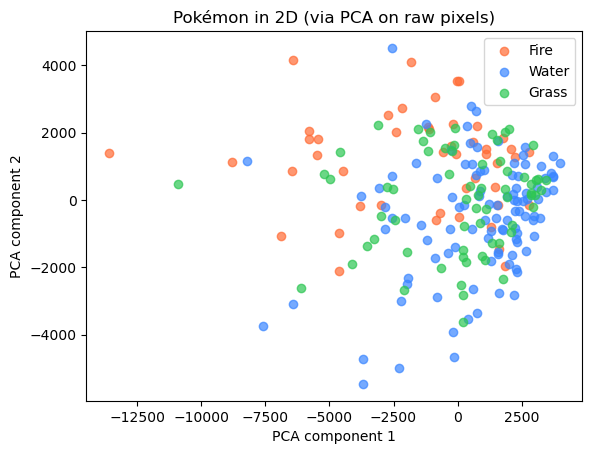

In [53]:
# Plot one colour per type
type_colours = {"Fire": "#FF6B35", "Water": "#3A86FF", "Grass": "#2DC653"}
for t in chosen_types:
    mask = (y == t)
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], c=type_colours[t], label=t, alpha=0.7)

plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.title("Pokémon in 2D (via PCA on raw pixels)")
plt.legend()
plt.show()

## Train models on PCA features

In [54]:
# Random Forest on PCA features
rf_pca = RandomForestClassifier(n_estimators=100, random_state=42)
rf_pca.fit(Xp_train_pca, y_train)
rf_pca_accuracy = accuracy_score(y_test, rf_pca.predict(Xp_test_pca))
print(f"Random Forest on PCA features: {rf_pca_accuracy:.1%}")

Random Forest on PCA features: 58.2%


In [57]:
# Logistic Regression on PCA features
lr_pca = LogisticRegression(max_iter=5000, random_state=42)
lr_pca.fit(Xp_train_pca, y_train)
lr_pca_accuracy = accuracy_score(y_test, lr_pca.predict(Xp_test_pca))
print(f"Logistic Regression on PCA features: {lr_pca_accuracy:.1%}")

Logistic Regression on PCA features: 65.5%


/opt/homebrew/Caskroom/miniconda/base/envs/isa383/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## The grand comparison — all five models

In [58]:
all_names = [
    "RF\n(3 features)",
    "RF tuned\n(3 features)",
    "LR\n(3 features)",
    "RF\n(50 PCA)",
    "LR\n(50 PCA)",
]
all_scores = [rf_accuracy, rf_tuned_accuracy, lr_accuracy, rf_pca_accuracy, lr_pca_accuracy]

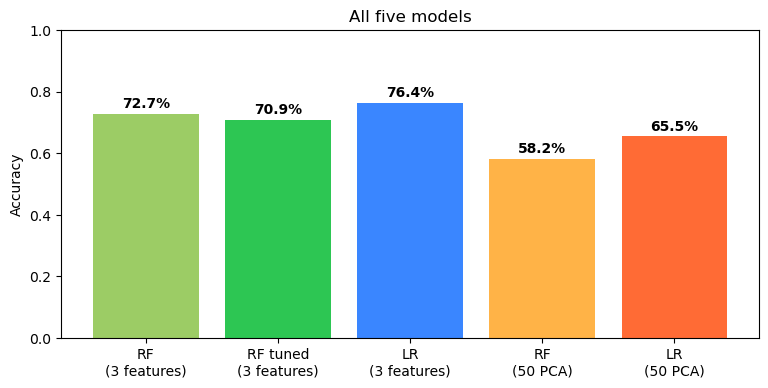

In [59]:
colours = ["#9CCC65", "#2DC653", "#3A86FF", "#FFB347", "#FF6B35"]
plt.figure(figsize=(9, 4))
plt.bar(all_names, all_scores, color=colours)
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("All five models")
for i, score in enumerate(all_scores):
    plt.text(i, score + 0.02, f"{score:.1%}", ha="center", fontweight="bold")
plt.show()

## Lesson 3 — Good features beat fancy techniques

**Surprised?** Even using 50 PCA components built from 43,200 raw pixels, neither model beat the simple 3 average-colour features.

> **Lesson 3:** Good, domain-relevant features can beat fancy techniques like dimensionality reduction.

Why? The 3 features encode exactly what matters for this problem (overall colour). PCA on raw pixels also captures position, shape, and noise — variation we don't actually need for telling Fire from Water from Grass.

PCA is still extremely useful — for visualisation (as we saw above), for genuinely high-dimensional problems, and for noise reduction in the right setting. But it is not a silver bullet.